## Nome: Caio Semblano Silva
## Matrícula: 621

---

# Atividade 4 - Algoritmos e Métodos Numéricos, Sistemas Lineares e o Método de Gauss-Seidel

Uma equipe de engenheiros está projetando o sistema de resfriamento líquido de um Data Center. A malha de tubulação possui diversos pontos de junção (nós), e a temperatura em cada um desses nós depende da temperatura dos nós vizinhos, formando um **sistema de equações lineares**.

Para uma malha pequena, com apenas 3 nós de interesse ($T_1$, $T_2$ e $T_3$), o balanço térmico do sistema resultou nas seguintes equações:

$$10T_1 - T_2 + 2T_3 = 6$$
$$-T_1 + 11T_2 - T_3 = 25$$
$$2T_1 - T_2 + 10T_3 = -11$$

Em sistemas reais, porém, a malha de tubulação de um Data Center pode ter **milhares de nós**, tornando a resolução do sistema por métodos diretos (como Eliminação de Gauss ou Regra de Cramer) computacionalmente muito custosa. Por isso, a equipe decidiu utilizar um **método iterativo**: o **Método de Gauss-Seidel**, que aproxima a solução do sistema a partir de sucessivas iterações, sem a necessidade de inverter ou triangularizar a matriz de coeficientes.

Seu objetivo é implementar o Método de Gauss-Seidel para resolver esse sistema, analisando sua convergência.


---

In [2]:
from IPython.display import display
# Importando bibliotecas

#Analise de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


<span style="font-size:90%">

**Guia Rápido: Gauss-Seidel com Python**

- Criar matriz de zeros: `np.zeros(n)`  
- Copiar um vetor (evitar sobrescrever): `x_antigo = x.copy()`  
- Somar elementos de uma linha, exceto a diagonal: `np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x_antigo[i+1:])`  
- Resolver sistema pelo método direto: `np.linalg.solve(A, b)`  
- Adicionar uma linha a um DataFrame já existente: `df.loc[len(df)] = [valores]`  

</span>

In [3]:
# funções auxiliares:

def eh_diagonalmente_dominante(A):
    n = A.shape[0]
    dominante = True
    for i in range(n):
        diagonal = np.abs(A[i, i])
        soma_resto = np.sum(np.abs(A[i, :])) - diagonal
        print(f"Linha {i+1}: |a_{{{i+1}{i+1}}}| = {diagonal:.2f}  |  soma dos demais = {soma_resto:.2f}  ->",
            "OK" if diagonal > soma_resto else "NÃO satisfaz")
        if diagonal <= soma_resto:
            dominante = False
    return dominante

def gauss_seidel(A, b, x0=None, tol=1e-4, max_iter=50):
    n = len(b)
    x = np.zeros(n) if x0 is None else x0.copy()
    historico = [x.copy()]

    for k in range(1, max_iter + 1):
        x_antigo = x.copy()
        for i in range(n):
            soma1 = np.dot(A[i, :i], x[:i])          # valores já atualizados (iteração atual)
            soma2 = np.dot(A[i, i+1:], x_antigo[i+1:])  # valores ainda não atualizados (iteração anterior)
            x[i] = (b[i] - soma1 - soma2) / A[i, i]

        historico.append(x.copy())
        erro = np.max(np.abs(x - x_antigo))

        if erro < tol:
            print(f"Convergiu na iteração {k} (erro = {erro:.2e})")
            break
    else:
        print(f"Número máximo de iterações ({max_iter}) atingido sem convergir para a tolerância definida.")

    return x, np.array(historico)

# Função para plotar a convergência do erro entre iterações consecutivas

def plot_convergencia(historico, titulo="Convergência do Método de Gauss-Seidel"):
    historico = np.array(historico)
    erros = np.max(np.abs(np.diff(historico, axis=0)), axis=1)
    iteracoes = np.arange(1, len(erros) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(iteracoes, erros, marker="o")
    plt.yscale("log")
    plt.xlabel("Iteração")
    plt.ylabel("Erro máximo entre iterações (escala log)")
    plt.title(titulo)
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.show()

In [5]:
# Sistema de equações na forma A.x = b

A = np.array([
    [10, -1,  2],
    [-1, 11, -1],
    [ 2, -1, 10]
], dtype=float)

b = np.array([6, 25, -11], dtype=float)

# Tabela de coeficientes para visualização
tabela = pd.DataFrame(A, columns=["T1", "T2", "T3"], index=["Eq. 1", "Eq. 2", "Eq. 3"])
tabela["b"] = b
display(tabela)


,T1,T2,T3,b
Eq. 1,10.0,-1.0,2.0,6.0
Eq. 2,-1.0,11.0,-1.0,25.0
Eq. 3,2.0,-1.0,10.0,-11.0


### Parte 1 - Verificação da Convergência (Dominância Diagonal)

Antes de aplicar o método, verifique se a matriz de coeficientes $A$ é **estritamente diagonalmente dominante**. Essa é uma condição *suficiente* (mas não necessária) para garantir a convergência do método de Gauss-Seidel.

In [9]:
eh_diagonalmente_dominante(A)
print("Portanto é estritamente diagonalmente dominante")

Linha 1: |a_{11}| = 10.00  |  soma dos demais = 3.00  -> OK
Linha 2: |a_{22}| = 11.00  |  soma dos demais = 2.00  -> OK
Linha 3: |a_{33}| = 10.00  |  soma dos demais = 3.00  -> OK
Portanto é estritamente diagonalmente dominante


**Formulário - Critério de Dominância Diagonal**

Uma matriz $A$, de ordem $n$, é estritamente diagonalmente dominante se, para toda linha $i$:

$$|a_{ii}| > \sum_{\substack{j=1 \\ j \neq i}}^{n} |a_{ij}|$$

Ou seja, o valor absoluto do elemento da diagonal principal deve ser maior que a soma dos valores absolutos dos demais elementos da mesma linha.

### Parte 2 - Implementação do Método de Gauss-Seidel

Implemente o Método de Gauss-Seidel para resolver o sistema $A \cdot x = b$.

Utilize:
- Estimativa inicial: $x^{(0)} = [0, 0, 0]$
- Tolerância: $\varepsilon = 10^{-4}$
- Número máximo de iterações: $50$

In [12]:
gauss_seidel(A, b)

Convergiu na iteração 5 (erro = 2.62e-05)


(array([ 1.04327066,  2.26923043, -1.08173109]),
 array([[ 0.        ,  0.        ,  0.        ],
        [ 0.6       ,  2.32727273, -0.98727273],
        [ 1.03018182,  2.2766281 , -1.07837355],
        [ 1.04333752,  2.26954218, -1.08171329],
        [ 1.04329688,  2.26923487, -1.08173589],
        [ 1.04327066,  2.26923043, -1.08173109]]))

**Formulário - Método de Gauss-Seidel**

Para cada variável $x_i$, na iteração $k+1$:

$$x_i^{(k+1)} = \frac{1}{a_{ii}}\left(b_i - \sum_{j < i} a_{ij}\,x_j^{(k+1)} - \sum_{j > i} a_{ij}\,x_j^{(k)}\right)$$

Onde:
- $a_{ii}$ = elemento da diagonal principal
- $x_j^{(k+1)}$ = valores já atualizados na iteração atual ($j < i$)
- $x_j^{(k)}$ = valores da iteração anterior ($j > i$)

**Critério de Parada:**

$$\max_i \left| x_i^{(k+1)} - x_i^{(k)} \right| < \varepsilon$$

### Parte 3 - Tabela de Iterações

Armazene os valores de $x_1$, $x_2$ e $x_3$ obtidos em cada iteração em um DataFrame, permitindo visualizar como a solução converge ao longo do processo.

In [13]:
x_final, historico_x = gauss_seidel(A, b)

tabela_iteracoes = pd.DataFrame(historico_x, columns=["x1", "x2", "x3"])

tabela_iteracoes.index.name = "Iteração"

display(tabela_iteracoes)

Convergiu na iteração 5 (erro = 2.62e-05)


,x1,x2,x3
Iteração,,,
0,0.000000,0.000000,0.000000
1,0.600000,2.327273,-0.987273
2,1.030182,2.276628,-1.078374
3,1.043338,2.269542,-1.081713
4,1.043297,2.269235,-1.081736
5,1.043271,2.269230,-1.081731


### Parte 4 - Comparação com a Solução Exata

Resolva o mesmo sistema utilizando um método direto (`np.linalg.solve`) e compare com o resultado obtido pelo Gauss-Seidel, calculando o **Erro Absoluto** e o **Erro Percentual** para cada variável.

In [14]:
x_exato = np.linalg.solve(A, b)

erro_absoluto = np.abs(x_exato - x_final)
erro_percentual = (erro_absoluto / np.abs(x_exato)) * 100

df_comparacao = pd.DataFrame({
    "Solução Exata (np.linalg)": x_exato,
    "Sol. Aprox (Gauss-Seidel)": x_final,
    "Erro Absoluto": erro_absoluto,
    "Erro Percentual (%)": erro_percentual
}, index=["x1", "x2", "x3"])

display(df_comparacao)

,Solução Exata (np.linalg),Sol. Aprox (Gauss-Seidel),Erro Absoluto,Erro Percentual (%)
x1,1.043269,1.043271,1.433973e-06,0.000137
x2,2.269231,2.269230,3.349682e-07,0.000015
x3,-1.081731,-1.081731,3.202915e-07,0.000030


### Parte 5 - Gráfico de Convergência

Construa um gráfico mostrando a evolução do erro (diferença entre iterações consecutivas) a cada iteração, para visualizar a convergência do método.

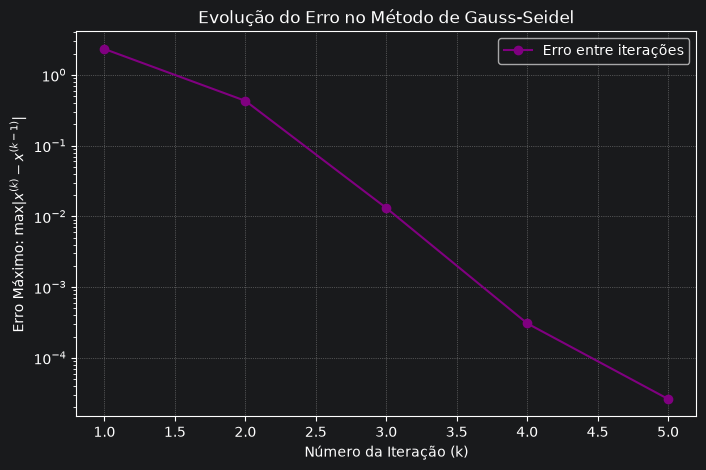

In [16]:
import matplotlib.pyplot as plt

# 1. Calcular o erro (diferença máxima) entre cada iteração consecutiva
erros_iteracao = []

for i in range(1, len(historico_x)):
    erro = np.max(np.abs(historico_x[i] - historico_x[i-1]))
    erros_iteracao.append(erro)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(historico_x)), erros_iteracao, marker='o', color='purple', label='Erro entre iterações')

plt.yscale('log')

plt.title('Evolução do Erro no Método de Gauss-Seidel', fontsize=12)
plt.xlabel('Número da Iteração (k)', fontsize=10)
plt.ylabel('Erro Máximo: $\\max|x^{(k)} - x^{(k-1)}|$', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.show()

## Parte Teórica

**Questão 1.**

Julgue as afirmativas abaixo como V (Verdadeiro) ou F (Falso) e justifique as que forem Falsas.

1. O método de Gauss-Seidel converge para qualquer sistema linear, independentemente das características da matriz de coeficientes.

2. Na atualização de cada variável, o método de Gauss-Seidel utiliza os valores já atualizados na iteração atual, diferentemente do método de Jacobi, que utiliza apenas os valores da iteração anterior.

3. Uma condição suficiente (mas não necessária) para a convergência do método de Gauss-Seidel é que a matriz dos coeficientes seja estritamente diagonalmente dominante.

4. O critério de parada de um método iterativo pode ser baseado na diferença entre os valores de uma variável em duas iterações consecutivas.

5. Métodos iterativos, como o Gauss-Seidel, são geralmente mais vantajosos do que métodos diretos (como a Eliminação de Gauss) para resolver sistemas lineares de qualquer tamanho, inclusive sistemas pequenos e densos.

**Resposta:**

1. F - O método não funciona para qualquer caso. A convergência depende fortemente das propriedades da matriz de coeficientes $A$. Se A matriz não cumprir certos requisitos (como ser estritamente diagonalmente dominante ou ser simétrica e definida positiva), o algoritmo pode divergir (os valores explodem mpara o infinito) em vez de encontrar a solução.
2. V
3. v
4. V
5. F - Para Sistemas lineares pequenos e densos (matrizes cheias de valores diferentes de zero), os métodos diretos (como a Eliminação de Gauss ou decomposição de LU) são muito mais vantajosos , pois encontram a solução exata em um número fixo e rápido de operações. OS métodos iterativos, como o Gauss-Seidel, mostram sua verdadeira força e vantagem apenas em sistemas gigantescos e esparsos (com milhares de variáveis, mas cheios de zeros), onde métodos diretos consumiram muita memória e tempo de processamento.

**Questão 2.**

Explique, com suas palavras, a principal diferença entre o Método de Jacobi e o Método de Gauss-Seidel, e justifique por que o método de Gauss-Seidel costuma convergir mais rapidamente.

**Resposta:**
- No Método de Jacobi, o algoritmo congela os resultados da rodada anterior ($k-1$) e usa exclusivamente eles para calcular todos os novos valores da rodada atual ($k$).
- No Método de Gauss-Seidel, as variáveis são atualizadas de forma sequencial e em cascata. Assim que o algoritmo calcula o novo valor de $x_1$, ele já o utiliza imediatamente na equação debaixo para calcular $x_2$, que por sua vez será usado junto com $x_1$ para calcular $x_3$, tudo dentro da mesma iteração.

O Gauss-Seidel costuma convergir mais rapidamente porque ele se aproveita da informação mais recente e precisa disponível. Como a cada nova linha calculada o valor recém-descoberto teoricamente tem um erro menor que o da iteração passada, propagar essa melhora imediatamente para as equações seguintes faz com que o método caminhe em direção à resposta correta dando "passos" mais largos e eficientes do que o método de Jacobi.